In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from scipy.stats import randint, ks_2samp
from imblearn.over_sampling import SMOTE
import shap
import joblib
import datetime
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv(r"C:\Users\mzalendo_ke\Documents\Project\loan.csv")

In [7]:
# Load and Initial Checks
df.head(20)
print("Initial shape:", df.shape)
df.head()

Initial shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df = df.drop('Loan_ID', axis=1)

In [11]:
# Missing Value Handling
imputer = SimpleImputer(strategy='median')  # More robust than mean
df['LoanAmount'] = imputer.fit_transform(df[['LoanAmount']])
df['Loan_Amount_Term'] = imputer.fit_transform(df[['Loan_Amount_Term']])
df['Credit_History'] = imputer.fit_transform(df[['Credit_History']])

In [13]:
# Feature Engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['Debt_to_Income_Ratio'] = df['LoanAmount'] / (df['TotalIncome'] + 1)
df['Loan_to_Income_Ratio'] = df['LoanAmount'] / (df['ApplicantIncome'] + 1)
df['Income_Stability'] = df['ApplicantIncome'] / (df['CoapplicantIncome'] + 1)

In [15]:
print(df.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome', 'EMI', 'Debt_to_Income_Ratio', 'Loan_to_Income_Ratio',
       'Income_Stability'],
      dtype='object')


In [17]:
# Label encode 'Loan_Status'
df['Loan_Status'] = LabelEncoder().fit_transform(df['Loan_Status'])

# List of columns to encode
categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Encode only existing categorical columns
existing_columns = [col for col in categorical_columns if col in df.columns]
if existing_columns:
    df = pd.get_dummies(df, columns=existing_columns, drop_first=True)
else:
    print("No categorical columns found to encode.")

In [19]:
# Scaling with Pipeline Integration
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
                     'Loan_Amount_Term', 'TotalIncome', 'EMI',
                     'Debt_to_Income_Ratio', 'Loan_to_Income_Ratio', 'Income_Stability']
scaler = StandardScaler()	
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [21]:
# Train-Test Split with Stratification
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# EDA Suite
def perform_eda(X_train, y_train, numerical_features):
# Target Distribution
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.countplot(x=y_train)
    plt.title("Training Set Class Distribution")

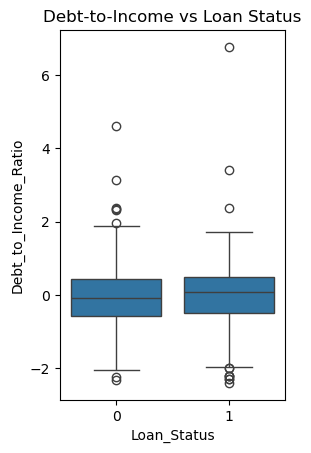

In [25]:
# Feature-Target Relationships
plt.subplot(1, 2, 2)	
sns.boxplot(x=y_train, y=X_train['Debt_to_Income_Ratio'])
plt.title("Debt-to-Income vs Loan Status")
plt.show()

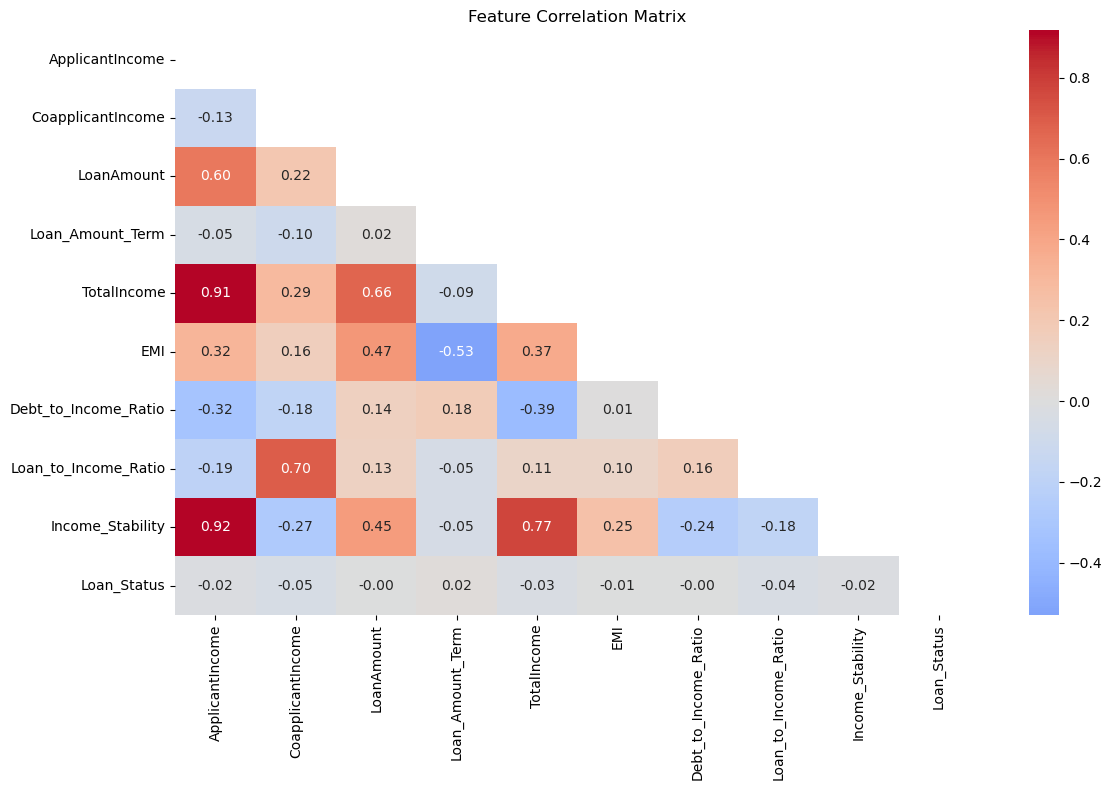

In [27]:
# Correlation Matrix
plt.figure(figsize=(12, 8))

# Get numeric columns (automatically excludes Loan_ID and other non-numeric)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
corr_data = pd.concat([X_train[numeric_cols], y_train], axis=1)

# Calculate correlation for ALL numeric features first
full_corr_matrix = corr_data.corr()

# Then select the features I want to display
display_features = numerical_features + ['Loan_Status']
display_corr = full_corr_matrix.loc[display_features, display_features]

# Create mask of the same shape as the DISPLAYED correlation matrix
mask = np.triu(np.ones_like(display_corr, dtype=bool))

# Plot with correct dimensions
sns.heatmap(display_corr, 
            annot=True, cmap='coolwarm',
            center=0, fmt=".2f",
            mask=mask)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

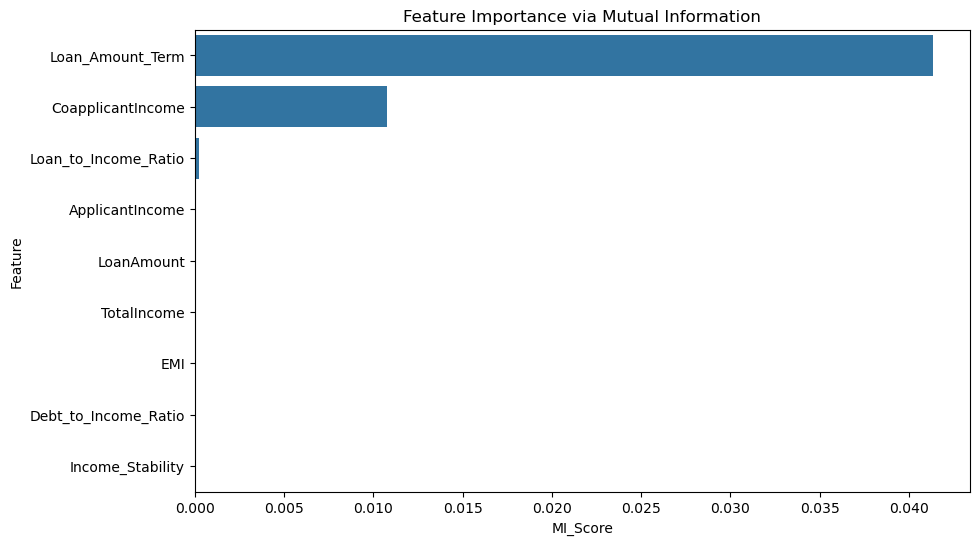

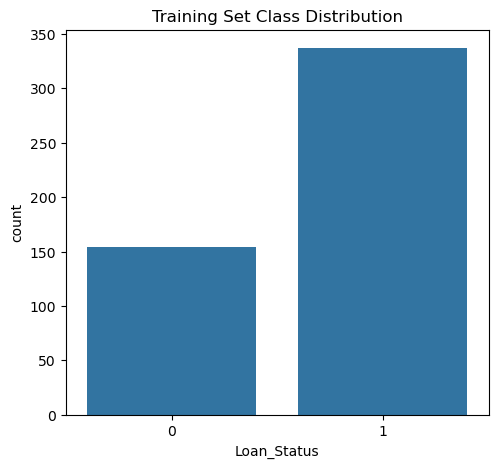

In [29]:
# Calculate Mutual Information
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train[numerical_features], y_train, random_state=42)
# Mutual Information
mi_scores = mutual_info_classif(X_train[numerical_features], y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': numerical_features, 'MI_Score': mi_scores})\
.sort_values('MI_Score', ascending=False)
    
plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_df)
plt.title("Feature Importance via Mutual Information")
plt.show()

perform_eda(X_train, y_train, numerical_features)

In [31]:
# FEATURE SELECTION (FIXED VERSION)

# First, ensure I'm only using numeric features
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
print(f"Original features: {X_train.shape[1]}\nNumeric features: {len(numeric_cols)}")

# Initialize and fit RFECV on numeric columns only
selector = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    step=1,
    cv=5,
    scoring='accuracy',
    min_features_to_select=10
)
selector.fit(X_train[numeric_cols], y_train)  # Only use numeric columns

# Get selected features
X_train_sel = selector.transform(X_train[numeric_cols])
X_test_sel = selector.transform(X_test[numeric_cols])
selected_features = numeric_cols[selector.support_]
print(f"\nSelected Features ({len(selected_features)}):\n{list(selected_features)}")

# Verify the selected features
print("\nSample of selected data:")
print(pd.DataFrame(X_train_sel, columns=selected_features).head())

Original features: 19
Numeric features: 10

Selected Features (10):
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'EMI', 'Debt_to_Income_Ratio', 'Loan_to_Income_Ratio', 'Income_Stability']

Sample of selected data:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0        -0.352136          -0.554487   -1.139385          0.273231   
1        -0.342142          -0.554487   -0.592018          0.273231   
2        -0.338047           0.030355    0.050543          0.273231   
3        -0.450595          -0.041468   -0.389730         -2.522836   
4        -0.456001           0.205808    0.050543          0.273231   

   Credit_History  TotalIncome       EMI  Debt_to_Income_Ratio  \
0             1.0    -0.584297 -0.655544             -0.978603   
1             1.0    -0.574845 -0.405352              0.583979   
2             0.0    -0.305994 -0.111648              0.669820   
3             0.0    -0.444991  

In [32]:
print("Data types in X_train:")
print(X_train.dtypes.value_counts())

Data types in X_train:
float64    10
bool        9
Name: count, dtype: int64


In [35]:
# Automated Feature Selection
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42), 
    threshold='median'
)
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)
print(f"Features reduced from {X_train.shape[1]} to {X_train_sel.shape[1]}")


Features reduced from 19 to 10


In [37]:
# Handle Class Imbalance (SMOTE)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [39]:
from sklearn.model_selection import train_test_split

# Split Data into Training, Validation, and Test Sets
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

In [41]:
# Train and Evaluate Base Models
log_reg = LogisticRegression(class_weight='balanced')
log_reg.fit(X_train_final, y_train_final)
y_pred_log_reg = log_reg.predict(X_val)
print("Logistic Regression:")	
print(f"Accuracy: {accuracy_score(y_val, y_pred_log_reg)}")
print(f"Precision: {precision_score(y_val, y_pred_log_reg)}")
print(f"Recall: {recall_score(y_val, y_pred_log_reg)}")
print(f"F1 Score: {f1_score(y_val, y_pred_log_reg)}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_pred_log_reg)}")

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_final, y_train_final)
y_pred_rf = rf.predict(X_val)
print("Random Forest:")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf)}")
print(f"Precision: {precision_score(y_val, y_pred_rf)}")
print(f"Recall: {recall_score(y_val, y_pred_rf)}")
print(f"F1 Score: {f1_score(y_val, y_pred_rf)}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_pred_rf)}")

xgb = XGBClassifier(scale_pos_weight=len(y_train_final[y_train_final == 0]) / len(y_train_final[y_train_final == 1]), random_state=42)
xgb.fit(X_train_final, y_train_final)
y_pred_xgb = xgb.predict(X_val)
print("XGBoost:")
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb)}")
print(f"Precision: {precision_score(y_val, y_pred_xgb)}")
print(f"Recall: {recall_score(y_val, y_pred_xgb)}")
print(f"F1 Score: {f1_score(y_val, y_pred_xgb)}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_pred_xgb)}")

Logistic Regression:
Accuracy: 0.7337278106508875
Precision: 0.7166666666666667
Recall: 0.8865979381443299
F1 Score: 0.7926267281105991
AUC-ROC: 0.7071878579610538
Random Forest:
Accuracy: 0.8165680473372781
Precision: 0.83
Recall: 0.8556701030927835
F1 Score: 0.8426395939086294
AUC-ROC: 0.8097794959908362
XGBoost:
Accuracy: 0.7928994082840237
Precision: 0.81
Recall: 0.8350515463917526
F1 Score: 0.8223350253807107
AUC-ROC: 0.7855813287514319


In [43]:
from sklearn.ensemble import RandomForestClassifier

# Define the base model
rf = RandomForestClassifier(random_state=42)

In [45]:
# Hyperparameter Tuning with Random Search
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 20)
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train_final, y_train_final)
best_rf_random = random_search.best_estimator_

y_pred_best_rf_random = best_rf_random.predict(X_val)
print("Best Random Forest (Random Search):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_best_rf_random)}")
print(f"Precision: {precision_score(y_val, y_pred_best_rf_random)}")
print(f"Recall: {recall_score(y_val, y_pred_best_rf_random)}")
print(f"F1 Score: {f1_score(y_val, y_pred_best_rf_random)}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_pred_best_rf_random)}")

Best Random Forest (Random Search):
Accuracy: 0.8165680473372781
Precision: 0.8113207547169812
Recall: 0.8865979381443299
F1 Score: 0.8472906403940886
AUC-ROC: 0.8044100801832761


In [46]:
#Ensemble Methods (Random Forest + XGBoost)
ensemble_model = VotingClassifier(
    estimators=[
        ('random_forest', best_rf_random),
        ('xgboost', xgb)
    ],
    voting='soft'
)

ensemble_model.fit(X_train_final, y_train_final)
y_pred_ensemble = ensemble_model.predict(X_val)
print("Ensemble Model (Random Forest + XGBoost):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_ensemble)}")
print(f"Precision: {precision_score(y_val, y_pred_ensemble)}")
print(f"Recall: {recall_score(y_val, y_pred_ensemble)}")
print(f"F1 Score: {f1_score(y_val, y_pred_ensemble)}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_pred_ensemble)}")

Ensemble Model (Random Forest + XGBoost):
Accuracy: 0.8106508875739645
Precision: 0.8217821782178217
Recall: 0.8556701030927835
F1 Score: 0.8383838383838383
AUC-ROC: 0.8028350515463917


In [49]:
y_pred_rf_test = best_rf_random.predict(X_test_final)

print("Random Forest Test Set Performance:")
print(f"Accuracy: {accuracy_score(y_test_final, y_pred_rf_test)}")
print(f"Precision: {precision_score(y_test_final, y_pred_rf_test)}")
print(f"Recall: {recall_score(y_test_final, y_pred_rf_test)}")
print(f"F1 Score: {f1_score(y_test_final, y_pred_rf_test)}")
print(f"AUC-ROC: {roc_auc_score(y_test_final, y_pred_rf_test)}")

Random Forest Test Set Performance:
Accuracy: 0.757396449704142
Precision: 0.6808510638297872
Recall: 0.8533333333333334
F1 Score: 0.757396449704142
AUC-ROC: 0.7670921985815603


In [51]:
# Measure Generalization Error on Test Set
y_pred_test_final = ensemble_model.predict(X_test_final)
print("Test Set Performance (Generalization Error):")
print(f"Accuracy: {accuracy_score(y_test_final, y_pred_test_final)}")
print(f"Precision: {precision_score(y_test_final, y_pred_test_final)}")
print(f"Recall: {recall_score(y_test_final, y_pred_test_final)}")
print(f"F1 Score: {f1_score(y_test_final, y_pred_test_final)}")
print(f"AUC-ROC: {roc_auc_score(y_test_final, y_pred_test_final)}")

Test Set Performance (Generalization Error):
Accuracy: 0.757396449704142
Precision: 0.6931818181818182
Recall: 0.8133333333333334
F1 Score: 0.7484662576687117
AUC-ROC: 0.7630496453900709


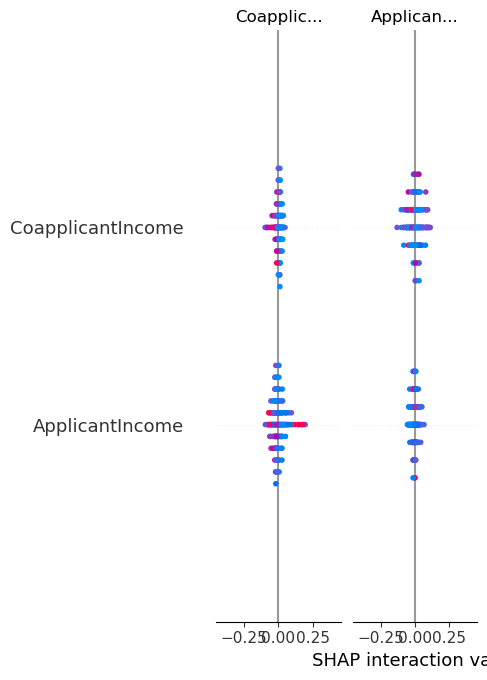

In [53]:
# Model Explainability with SHAP
explainer = shap.TreeExplainer(best_rf_random)
shap_values = explainer.shap_values(X_val)	
shap.summary_plot(shap_values, X_val, feature_names=X.columns)

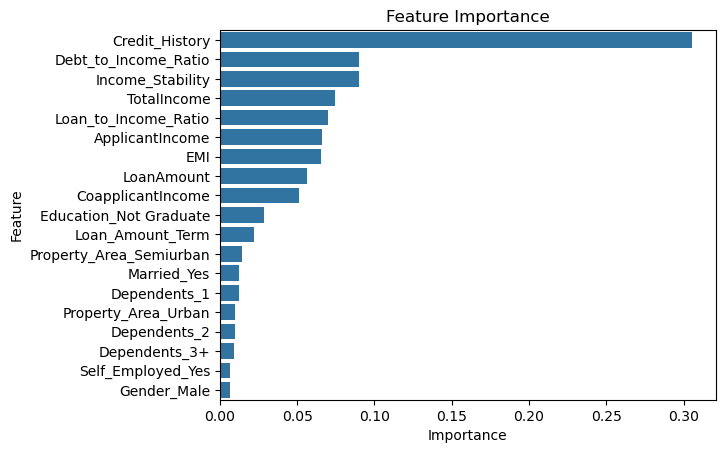

In [55]:
# Feature Importance and Confusion Matrix
feature_importances = best_rf_random.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()

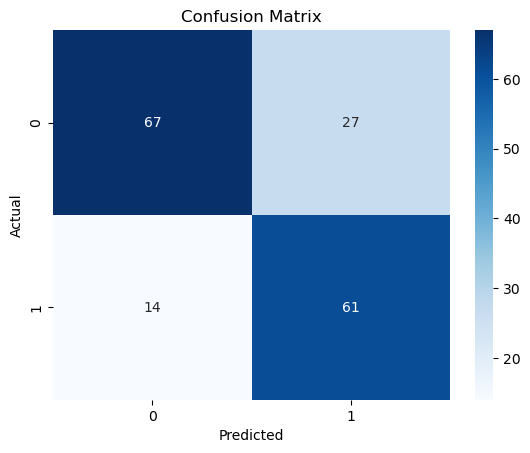

In [57]:
cm = confusion_matrix(y_test_final, y_pred_test_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [59]:
# Real-Time Model Monitoring for Concept Drift
# Set up a reference dataset (e.g., training data) and current dataset (e.g., new data)
reference_data = X_train_final.copy()
reference_data['Loan_Status'] = y_train_final
current_data = X_test_final.copy()
current_data['Loan_Status'] = y_test_final

In [61]:
from evidently.pipeline.column_mapping import ColumnMapping

# Create a ColumnMapping object
column_mapping = ColumnMapping()
column_mapping.target = 'Loan_Status'  # Set the target column

In [63]:
from evidently.report import Report
from evidently.metrics import DatasetDriftMetric

# Generate a Data Drift Report

data_drift_report = Report(metrics=[DatasetDriftMetric()])
data_drift_report.run(
    reference_data=reference_data,
    current_data=current_data,
    column_mapping=column_mapping
)
data_drift_report.save_html('data_drift_report.html') # Save report as HTML

In [65]:
# Store Predictions and Feedback for Continuous Learning

import sqlite3
# Create a SQLite database to store predictions and feedback
conn = sqlite3.connect('loan_predictions.db')
cursor = conn.cursor()

In [67]:
# Create a table to store predictions
cursor.execute('''
CREATE TABLE IF NOT EXISTS predictions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    applicant_id INTEGER,
    prediction INTEGER,
    actual_outcome INTEGER,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
)
''')
conn.commit()

In [69]:
# Store predictions and actual outcomes in the database
for i, (pred, actual) in enumerate(zip(y_pred_test_final, y_test_final)):
    cursor.execute('''
    INSERT INTO predictions (applicant_id, prediction, actual_outcome)
    VALUES (?, ?, ?)
    ''', (i, int(pred), int(actual)))
conn.commit()

In [71]:
# Retrain the Model Periodically
# Fetch new data with feedback from the database
cursor.execute('SELECT * FROM predictions')
new_data = cursor.fetchall()

In [73]:
# Convert new data into a DataFrame
new_data_df = pd.DataFrame(new_data, columns=['id', 'applicant_id', 'prediction', 'actual_outcome', 'timestamp'])

In [75]:
# Save the final model
joblib.dump(best_rf_random, 'loan_default_model.pkl')

['loan_default_model.pkl']

In [77]:
# Save the scaler and encoders for future use

numerical_features = [
    'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
    'Loan_Amount_Term', 'Credit_History'
]

categorical_features = [
    'Gender', 'Married', 'Dependents', 
    'Education', 'Self_Employed', 'Property_Area'
]

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numerical pipeline
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [83]:
# Raw column lists (adjust if necessary)
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                      'Loan_Amount_Term', 'Credit_History']

categorical_features = ['Gender', 'Married', 'Dependents',
                        'Education', 'Self_Employed', 'Property_Area']

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define transformers
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [85]:
print(X_train.columns.tolist())

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'EMI', 'Debt_to_Income_Ratio', 'Loan_to_Income_Ratio', 'Income_Stability', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [87]:
# Reload the raw data (before encoding)
df = pd.read_csv(r"C:\Users\mzalendo_ke\Documents\Project\loan.csv")

# Split features and target
X_raw = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split again for preprocessor fitting
from sklearn.model_selection import train_test_split
X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

In [89]:
preprocessor.fit(X_raw_train)

import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

model_pipeline.fit(X_raw_train, y_train)

# Save complete model
joblib.dump(model_pipeline, 'loan_default_model.pkl')

['loan_default_model.pkl']

In [93]:
# Save the complete feature information
with open('feature_columns.json', 'w') as f:
    json.dump({
        'numerical_features': numerical_features,
        'original_categorical_columns': ['Gender', 'Married', 'Dependents', 
                                       'Education', 'Self_Employed', 'Property_Area'],
        'all_columns': list(X_train.columns),
        'target_column': 'Loan_Status'
    }, f)

In [95]:
import json

numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                      'Loan_Amount_Term', 'Credit_History']

categorical_features = ['Gender', 'Married', 'Dependents',
                        'Education', 'Self_Employed', 'Property_Area']

feature_info = {
    'numerical_features': numerical_features,
    'original_categorical_columns': categorical_features,
    'all_columns': numerical_features + categorical_features
}

with open('feature_columns.json', 'w') as f:
    json.dump(feature_info, f, indent=4)

In [97]:
def predict_loan_default(raw_input_json):
    """
    Predict loan default from raw JSON input.
    """
    # Load expected columns
    with open('feature_columns.json', 'r') as f:
        feature_info = json.load(f)

    expected_columns = feature_info['all_columns']

    # Load model pipeline (includes preprocessor)
    model = joblib.load('loan_default_model.pkl')

    # Convert input into DataFrame and reindex safely
    input_df = pd.DataFrame([raw_input_json])
    for col in expected_columns:
        if col not in input_df.columns:
            input_df[col] = np.nan
    input_df = input_df[expected_columns]

    # Predict
    probability = model.predict_proba(input_df)[0, 1]
    prediction = int(probability >= 0.5)

    return prediction, probability

In [99]:
# Model Testing & Prediction 

def calculate_engineered_features(data):
    """Calculate TotalIncome, EMI, etc. from base features"""
    if isinstance(data, dict):
        data = pd.DataFrame([data])
    
    if 'TotalIncome' not in data:
        data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']
    if 'EMI' not in data and 'LoanAmount' in data and 'Loan_Amount_Term' in data:
        data['EMI'] = data['LoanAmount'] / data['Loan_Amount_Term']
    if 'Debt_to_Income_Ratio' not in data and 'LoanAmount' in data and 'TotalIncome' in data:
        data['Debt_to_Income_Ratio'] = data['LoanAmount'] / (data['TotalIncome'] + 1)
    if 'Loan_to_Income_Ratio' not in data and 'LoanAmount' in data and 'ApplicantIncome' in data:
        data['Loan_to_Income_Ratio'] = data['LoanAmount'] / (data['ApplicantIncome'] + 1)
    if 'Income_Stability' not in data and 'ApplicantIncome' in data and 'CoapplicantIncome' in data:
        data['Income_Stability'] = data['ApplicantIncome'] / (data['CoapplicantIncome'] + 1)
    
    return data

In [101]:
import joblib
sample_data = {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "0",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 0,
    "LoanAmount": 128,
    "Loan_Amount_Term": 360,
    "Credit_History": 1.0,
    "Property_Area": "Urban"
}

pred, prob = predict_loan_default(sample_data)
print("Prediction:", pred)
print("Probability of Default:", round(prob, 3))

Prediction: 1
Probability of Default: 0.86


In [103]:
import pandas as pd
import joblib
import json
import numpy as np

def predict_loan_default(raw_input_json):
    """
    Predict loan default from raw JSON input with validation.
    Returns:
        (prediction, probability) or raises ValueError with details.
    """
    # Load feature structure
    with open('feature_columns.json', 'r') as f:
        feature_info = json.load(f)

    expected_columns = feature_info['all_columns']
    required_columns = set(expected_columns)

    # Load model
    model = joblib.load('loan_default_model.pkl')

    # Step 1: Validate Input
    missing_cols = required_columns - set(raw_input_json.keys())
    extra_cols = set(raw_input_json.keys()) - required_columns

    if missing_cols:
        raise ValueError(f"Missing input fields: {sorted(missing_cols)}")
    if extra_cols:
        print(f" Warning: Unused fields will be ignored: {sorted(extra_cols)}")

    # Step 2: Create aligned DataFrame
    input_df = pd.DataFrame([raw_input_json])
    input_df = input_df.reindex(columns=expected_columns, fill_value=np.nan)

    # Step 3: Predict
    try:
        probability = model.predict_proba(input_df)[0, 1]
        prediction = int(probability >= 0.5)
        return prediction, probability
    except Exception as e:
        # Optionally, log the full exception to a file or monitoring system
        raise RuntimeError(f"Prediction failed: {str(e)}")

In [105]:
sample_data = {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "0",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 0,
    "LoanAmount": 128,
    "Loan_Amount_Term": 360,
    "Credit_History": 1.0,
    "Property_Area": "Urban"
}

try:
    pred, prob = predict_loan_default(sample_data)
    print(f"Prediction: {pred} (0 = No Default, 1 = Default)")
    print(f"Probability of Default: {round(prob, 3)}")
except ValueError as ve:
    print(f"❌ Input Error: {ve}")
except RuntimeError as re:
    print(f"❌ Model Error: {re}")

Prediction: 1 (0 = No Default, 1 = Default)
Probability of Default: 0.86


In [107]:
import logging

# Set up logging
logging.basicConfig(filename='prediction_errors.log', level=logging.ERROR)

# Example list of missing fields
missing_cols = ['column1', 'column2', 'column3']

# Log the error
logging.error(f"Missing fields: {missing_cols}")

ERROR:root:Missing fields: ['column1', 'column2', 'column3']


In [109]:
# Load saved model pipeline (preprocessor + model)
import joblib

model_pipeline = joblib.load('loan_default_model.pkl')  # Update with your file path

# Predict using raw test data (X_raw_test must be your original test features, not encoded)
y_pred = model_pipeline.predict(X_raw_test)
y_prob = model_pipeline.predict_proba(X_raw_test)[:, 1]  # for AUC

In [115]:
from sklearn.metrics import classification_report


# Map string labels to numeric for evaluation
y_test_mapped = y_test.map({'Y': 1, 'N': 0})
y_pred_mapped = pd.Series(y_pred).map({'Y': 1, 'N': 0}) if isinstance(y_pred[0], str) else y_pred

# Calculate all key metrics
print("Classification Report:")
print(classification_report(y_test_mapped, y_pred_mapped))

print("Evaluation Metrics:")
print(f"✅ Accuracy:   {accuracy_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"✅ Precision:  {precision_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"✅ Recall:     {recall_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"✅ F1 Score:   {f1_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"✅ ROC-AUC:    {roc_auc_score(y_test_mapped, y_prob):.2f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123

Evaluation Metrics:
✅ Accuracy:   0.82
✅ Precision:  0.84
✅ Recall:     0.92
✅ F1 Score:   0.88
✅ ROC-AUC:    0.78


In [117]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Map target labels if they are 'Y'/'N'
y_test_mapped = y_test.map({'Y': 1, 'N': 0})
y_pred_mapped = pd.Series(y_pred).map({'Y': 1, 'N': 0}) if isinstance(y_pred[0], str) else y_pred

# Print a classification report
print("Test Set Evaluation Report:")
print(classification_report(y_test_mapped, y_pred_mapped))

# Print detailed metrics
print("Performance Metrics Summary:")
print(f"Accuracy:   {accuracy_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"Precision:  {precision_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"Recall:     {recall_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"F1 Score:   {f1_score(y_test_mapped, y_pred_mapped):.2f}")
print(f"ROC-AUC:    {roc_auc_score(y_test_mapped, y_prob):.2f}")

Test Set Evaluation Report:
              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123

Performance Metrics Summary:
Accuracy:   0.82
Precision:  0.84
Recall:     0.92
F1 Score:   0.88
ROC-AUC:    0.78


In [123]:
import zipfile
import os
from IPython.display import FileLink

# List of files to include in the zip
files_to_zip = [
    'loan_default_model.pkl',
    'preprocessor.pkl',
    'feature_columns.json',
    'data_drift_report.html',
    'loan_predictions.db',
]

# Create a zip file containing all the files
zip_filename = 'loan_default_model_files.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
        else:
            print(f"Warning: {file} not found and won't be included in the zip")

# Provide download link
if os.path.exists(zip_filename):
    display(FileLink(zip_filename, result_html_prefix="Download all model files: "))
else:
    print("No files were found to zip")

C:\Users\mzalendo_ke\loan_default_model_files.zip